
# 24ADI306 DEEP LEARNING — Assignment 3

## Comparative Analysis of RNN, LSTM, and GRU for Sentiment Analysis

**Student:** Mohamed Aashik S  
**Roll No:** 24BAD072  

## 1. Import Required Libraries


In [2]:
import os
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0



## 2. Reproducibility and Experiment Settings


In [3]:

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
RNN_UNITS = 64
BATCH_SIZE = 64
EPOCHS = 5

print("Experiment settings:")
print("Vocabulary size :", VOCAB_SIZE)
print("Maximum length  :", MAX_LEN)
print("Embedding dim   :", EMBEDDING_DIM)
print("Recurrent units :", RNN_UNITS)
print("Batch size      :", BATCH_SIZE)
print("Epochs          :", EPOCHS)


Experiment settings:
Vocabulary size : 10000
Maximum length  : 200
Embedding dim   : 128
Recurrent units : 64
Batch size      : 64
Epochs          : 5



## 3. Load the Built-in IMDB Sentiment Dataset



In [4]:
(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

y_train = np.array(y_train)
y_test = np.array(y_test)

print("Training samples :", len(x_train_raw))
print("Testing samples  :", len(x_test_raw))
print("First encoded review:", x_train_raw[0][:30])
print("First label:", y_train[0])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 25000
Testing samples  : 25000
First encoded review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]
First label: 1



## 4. Dataset Exploration


,Sentiment,Count
0,Negative,12500
1,Positive,12500


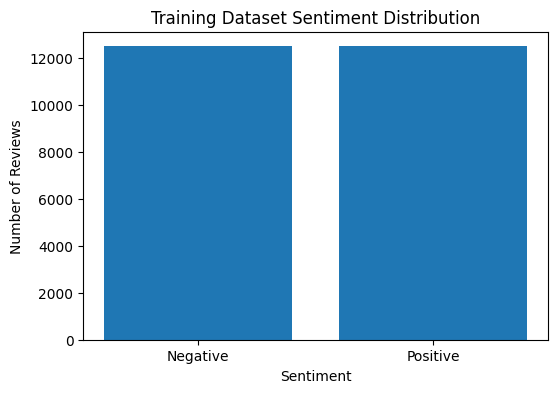

Minimum review length: 11
Maximum review length: 2494
Mean review length   : 238.71
Median review length : 178.0


In [5]:

class_counts = pd.Series(y_train).value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Sentiment": ["Negative", "Positive"],
    "Count": [class_counts.get(0, 0), class_counts.get(1, 0)]
})

display(class_distribution)

plt.figure(figsize=(6, 4))
plt.bar(class_distribution["Sentiment"], class_distribution["Count"])
plt.title("Training Dataset Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

train_lengths = np.array([len(seq) for seq in x_train_raw])

print("Minimum review length:", train_lengths.min())
print("Maximum review length:", train_lengths.max())
print("Mean review length   :", round(train_lengths.mean(), 2))
print("Median review length :", np.median(train_lengths))



## 5. Text Cleaning Demonstration



In [6]:

word_index = imdb.get_word_index()

reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

def decode_review(encoded_review):
    return " ".join(
        reverse_word_index.get(token_id, "<UNK>")
        for token_id in encoded_review
    )

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sample_raw_text = decode_review(x_train_raw[0])
sample_clean_text = clean_text(sample_raw_text)

print("Original decoded review:")
print(sample_raw_text[:1000])

print("\nCleaned review:")
print(sample_clean_text[:1000])


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original decoded review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for t


## 6. Tokenization



In [7]:

print("Encoded review:")
print(x_train_raw[0][:50])

print("\nNumber of tokens in first review:", len(x_train_raw[0]))
print("Label:", y_train[0], "(1 = Positive, 0 = Negative)")


Encoded review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447]

Number of tokens in first review: 218
Label: 1 (1 = Positive, 0 = Negative)



## 7. Padding



In [8]:

X_train = pad_sequences(
    x_train_raw,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    x_test_raw,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("One padded review shape:", X_train[0].shape)
print("\nFirst 50 padded token IDs:")
print(X_train[0][:50])


X_train shape: (25000, 200)
X_test shape : (25000, 200)
One padded review shape: (200,)

First 50 padded token IDs:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447]



## 8. Build the RNN Model


In [9]:

def build_rnn_model():
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),
        SimpleRNN(RNN_UNITS),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

rnn_model = build_rnn_model()
rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:


rnn_start_time = time.perf_counter()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

rnn_training_time = time.perf_counter() - rnn_start_time

print(f"\nRNN training time: {rnn_training_time:.2f} seconds")


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step - accuracy: 0.5044 - loss: 0.6949 - val_accuracy: 0.5072 - val_loss: 0.6930
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.6289 - loss: 0.6044 - val_accuracy: 0.5088 - val_loss: 0.7676
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 102ms/step - accuracy: 0.6432 - loss: 0.5938 - val_accuracy: 0.5040 - val_loss: 0.7986
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.6898 - loss: 0.4698 - val_accuracy: 0.4986 - val_loss: 0.9461
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.7311 - loss: 0.3942 - val_accuracy: 0.5196 - val_loss: 1.0431

RNN training time: 164.96 seconds



## 9. Evaluate the RNN Model


In [11]:

def evaluate_model(model, X_test, y_test, training_time, model_name):
    probabilities = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "Training Time (sec)": training_time
    }

    return metrics, predictions, probabilities

rnn_result, rnn_predictions, rnn_probabilities = evaluate_model(
    rnn_model,
    X_test,
    y_test,
    rnn_training_time,
    "RNN"
)

print(pd.DataFrame([rnn_result]).to_string(index=False))


Model  Accuracy  Precision  Recall  F1-Score  Training Time (sec)
  RNN   0.50504   0.504079  0.6228  0.557186           164.959323


RNN Classification Report
              precision    recall  f1-score   support

    Negative       0.51      0.39      0.44     12500
    Positive       0.50      0.62      0.56     12500

    accuracy                           0.51     25000
   macro avg       0.51      0.51      0.50     25000
weighted avg       0.51      0.51      0.50     25000



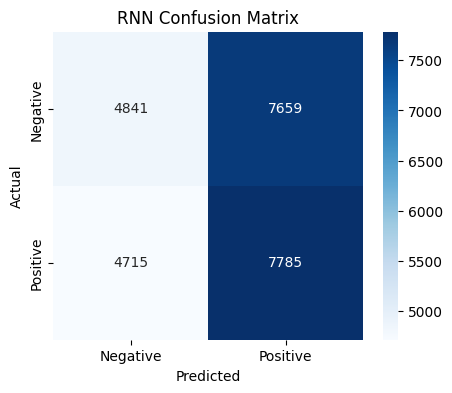

In [12]:

print("RNN Classification Report")
print(
    classification_report(
        y_test,
        rnn_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

rnn_cm = confusion_matrix(y_test, rnn_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



## 10. Build and Train the LSTM Model


In [13]:

def build_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),
        LSTM(RNN_UNITS),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_model = build_lstm_model()
lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:

lstm_start_time = time.perf_counter()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

lstm_training_time = time.perf_counter() - lstm_start_time

print(f"\nLSTM training time: {lstm_training_time:.2f} seconds")


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 262ms/step - accuracy: 0.5322 - loss: 0.6906 - val_accuracy: 0.5142 - val_loss: 0.6922
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 259ms/step - accuracy: 0.6028 - loss: 0.6448 - val_accuracy: 0.5494 - val_loss: 0.8625
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 262ms/step - accuracy: 0.6332 - loss: 0.6431 - val_accuracy: 0.6514 - val_loss: 0.6381
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 260ms/step - accuracy: 0.7184 - loss: 0.5619 - val_accuracy: 0.7262 - val_loss: 0.5996
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.8543 - loss: 0.3492 - val_accuracy: 0.8374 - val_loss: 0.3728

LSTM training time: 412.39 seconds


Model  Accuracy  Precision  Recall  F1-Score  Training Time (sec)
 LSTM   0.81008   0.901242 0.69648   0.78574           412.394556

LSTM Classification Report
              precision    recall  f1-score   support

    Negative       0.75      0.92      0.83     12500
    Positive       0.90      0.70      0.79     12500

    accuracy                           0.81     25000
   macro avg       0.83      0.81      0.81     25000
weighted avg       0.83      0.81      0.81     25000



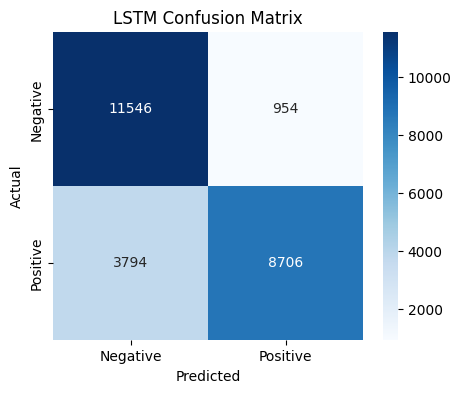

In [15]:

lstm_result, lstm_predictions, lstm_probabilities = evaluate_model(
    lstm_model,
    X_test,
    y_test,
    lstm_training_time,
    "LSTM"
)

print(pd.DataFrame([lstm_result]).to_string(index=False))

print("\nLSTM Classification Report")
print(
    classification_report(
        y_test,
        lstm_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

lstm_cm = confusion_matrix(y_test, lstm_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



## 11. Build and Train the GRU Model


In [16]:

def build_gru_model():
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),
        GRU(RNN_UNITS),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

gru_model = build_gru_model()
gru_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:


gru_start_time = time.perf_counter()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

gru_training_time = time.perf_counter() - gru_start_time

print(f"\nGRU training time: {gru_training_time:.2f} seconds")


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 291ms/step - accuracy: 0.5204 - loss: 0.6906 - val_accuracy: 0.5494 - val_loss: 0.6687
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 311ms/step - accuracy: 0.5569 - loss: 0.6865 - val_accuracy: 0.5496 - val_loss: 0.6768
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 290ms/step - accuracy: 0.7512 - loss: 0.5204 - val_accuracy: 0.7900 - val_loss: 0.4570
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 290ms/step - accuracy: 0.8844 - loss: 0.2881 - val_accuracy: 0.8536 - val_loss: 0.3443
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 292ms/step - accuracy: 0.9358 - loss: 0.1859 - val_accuracy: 0.8566 - val_loss: 0.3661

GRU training time: 616.33 seconds


Model  Accuracy  Precision  Recall  F1-Score  Training Time (sec)
  GRU   0.84384   0.837946 0.85256   0.84519           616.326515

GRU Classification Report
              precision    recall  f1-score   support

    Negative       0.85      0.84      0.84     12500
    Positive       0.84      0.85      0.85     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



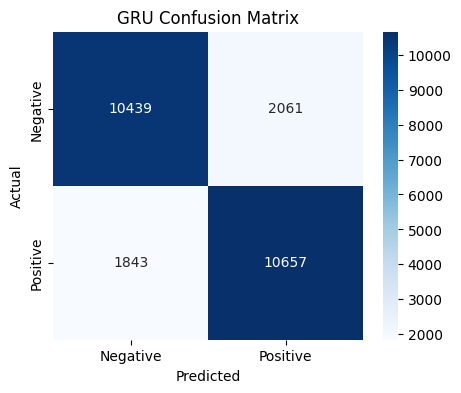

In [18]:

gru_result, gru_predictions, gru_probabilities = evaluate_model(
    gru_model,
    X_test,
    y_test,
    gru_training_time,
    "GRU"
)

print(pd.DataFrame([gru_result]).to_string(index=False))

print("\nGRU Classification Report")
print(
    classification_report(
        y_test,
        gru_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

gru_cm = confusion_matrix(y_test, gru_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    gru_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



## 12. Final Performance Comparison




In [19]:

results = pd.DataFrame([
    rnn_result,
    lstm_result,
    gru_result
])

display_table = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    display_table[column] = display_table[column] * 100

display_table["Accuracy"] = display_table["Accuracy"].round(2)
display_table["Precision"] = display_table["Precision"].round(2)
display_table["Recall"] = display_table["Recall"].round(2)
display_table["F1-Score"] = display_table["F1-Score"].round(2)
display_table["Training Time (sec)"] = display_table["Training Time (sec)"].round(2)

display_table.columns = [
    "Model",
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-Score (%)",
    "Training Time (sec)"
]

print("FINAL COMPARISON TABLE")
display(display_table)


FINAL COMPARISON TABLE


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Training Time (sec)
0,RNN,50.50,50.41,62.28,55.72,164.96
1,LSTM,81.01,90.12,69.65,78.57,412.39
2,GRU,84.38,83.79,85.26,84.52,616.33


In [20]:

results.to_csv("comparison_results.csv", index=False)

print("Saved: comparison_results.csv")


Saved: comparison_results.csv



## 13. Accuracy, F1-Score, and Training-Time Graphs



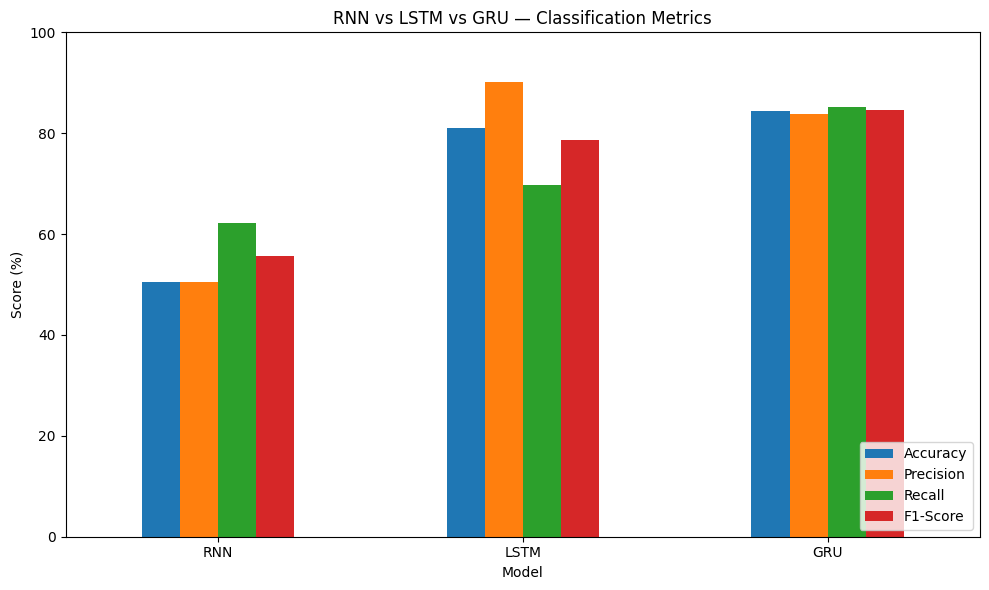

In [21]:

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]

plot_df = results.copy()

for metric in metrics_to_plot:
    plot_df[metric] = plot_df[metric] * 100

ax = plot_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("RNN vs LSTM vs GRU — Classification Metrics")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


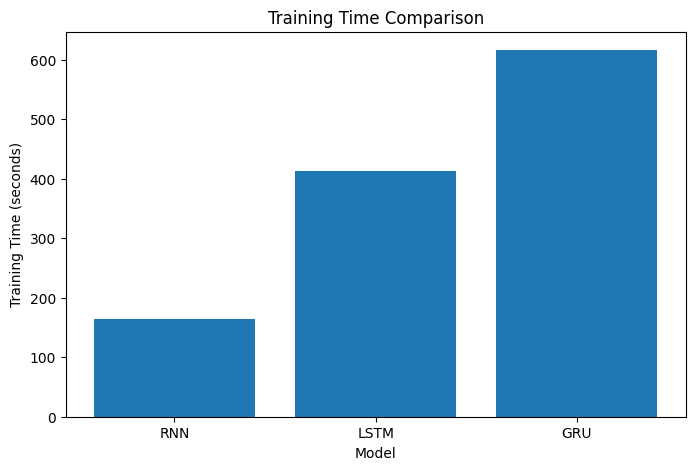

In [22]:

plt.figure(figsize=(8, 5))
plt.bar(
    results["Model"],
    results["Training Time (sec)"]
)
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.show()



## 14. Training and Validation Accuracy Curves



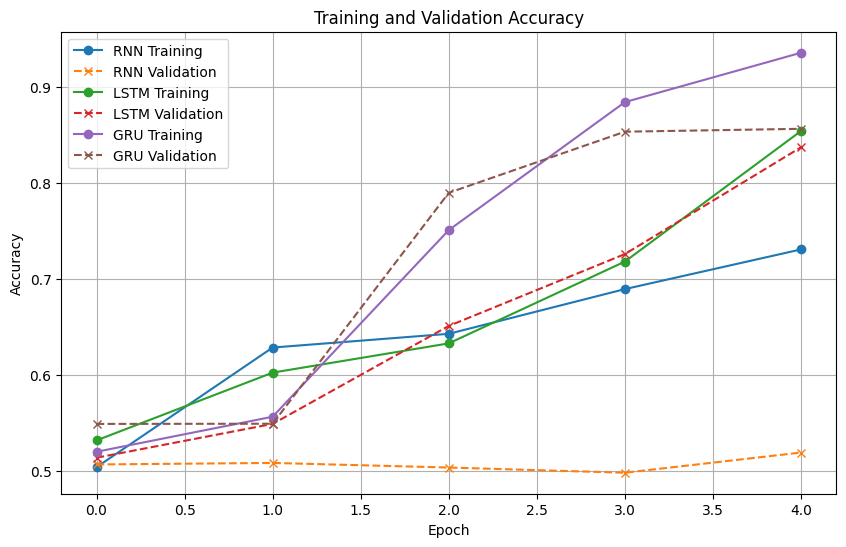

In [23]:

histories = {
    "RNN": rnn_history,
    "LSTM": lstm_history,
    "GRU": gru_history
}

plt.figure(figsize=(10, 6))

for model_name, history in histories.items():
    plt.plot(
        history.history["accuracy"],
        marker="o",
        label=f"{model_name} Training"
    )
    plt.plot(
        history.history["val_accuracy"],
        marker="x",
        linestyle="--",
        label=f"{model_name} Validation"
    )

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



## 15. Loss Curves



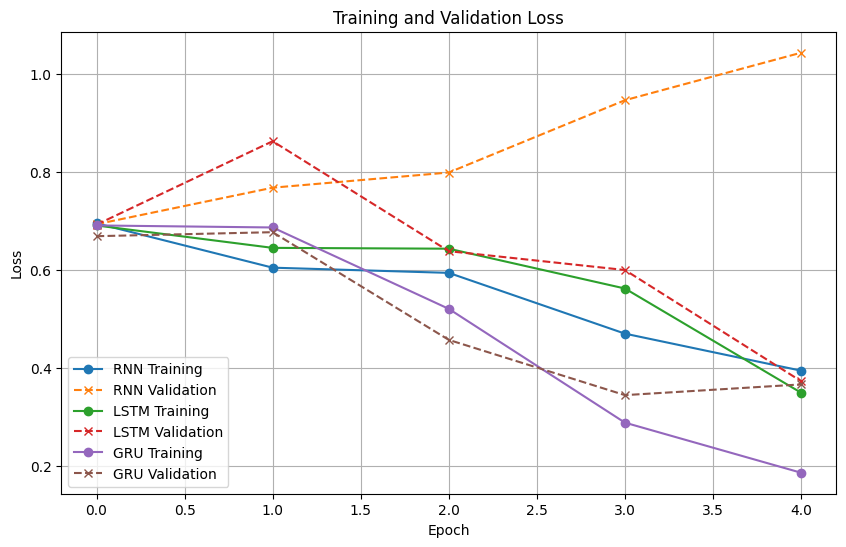

In [24]:

plt.figure(figsize=(10, 6))

for model_name, history in histories.items():
    plt.plot(
        history.history["loss"],
        marker="o",
        label=f"{model_name} Training"
    )
    plt.plot(
        history.history["val_loss"],
        marker="x",
        linestyle="--",
        label=f"{model_name} Validation"
    )

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



## 16. Automated Result Analysis


In [25]:

best_f1_row = results.loc[results["F1-Score"].idxmax()]

fastest_row = results.loc[results["Training Time (sec)"].idxmin()]

print("Model with highest measured F1-score:")
print(best_f1_row.to_string())

print("\nFastest training model:")
print(fastest_row.to_string())

print("\nDetailed observations:")
for _, row in results.iterrows():
    print(
        f"{row['Model']}: "
        f"Accuracy={row['Accuracy']*100:.2f}%, "
        f"Precision={row['Precision']*100:.2f}%, "
        f"Recall={row['Recall']*100:.2f}%, "
        f"F1={row['F1-Score']*100:.2f}%, "
        f"Training Time={row['Training Time (sec)']:.2f}s"
    )


Model with highest measured F1-score:
Model                         GRU
Accuracy                  0.84384
Precision                0.837946
Recall                    0.85256
F1-Score                  0.84519
Training Time (sec)    616.326515

Fastest training model:
Model                         RNN
Accuracy                  0.50504
Precision                0.504079
Recall                     0.6228
F1-Score                 0.557186
Training Time (sec)    164.959323

Detailed observations:
RNN: Accuracy=50.50%, Precision=50.41%, Recall=62.28%, F1=55.72%, Training Time=164.96s
LSTM: Accuracy=81.01%, Precision=90.12%, Recall=69.65%, F1=78.57%, Training Time=412.39s
GRU: Accuracy=84.38%, Precision=83.79%, Recall=85.26%, F1=84.52%, Training Time=616.33s
